# Explore here

It's recommended to use this notebook for exploration purposes.

In [11]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [88]:
import io
import sqlite3

In [119]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [3]:
webpage = "https://en.wikipedia.org/wiki/List_of_Spotify_streaming_records"

In [4]:
response = requests.get(webpage)

In [5]:
response

<Response [200]>

In [24]:

html = io.StringIO(response.text) 

dataset = pd.read_html(html)
print(f"{len(dataset)} tables were found.")

27 tables were found.


In [26]:
dataset[0]

,Rank,Song,Artist(s),Streams (billions),Release date,Ref.
0,1,"""Blinding Lights""",The Weeknd,4.810,29 November 2019,[2]
1,2,"""Shape of You""",Ed Sheeran,4.330,6 January 2017,[3]
2,3,"""Someone You Loved""",Lewis Capaldi,3.881,8 November 2018,[4]
3,4,"""Starboy""",The Weeknd and Daft Punk,3.860,21 September 2016,[5]
4,5,"""As It Was""",Harry Styles,3.850,1 April 2022,[6]
...,...,...,...,...,...,...
96,97,"""Stay With Me""",Sam Smith,2.282,14 April 2014,[98]
97,98,"""Someone Like You""",Adele,2.273,24 January 2011,[99]
98,99,"""Havana""",Camila Cabello and Young Thug,2.269,3 August 2017,[100]
99,100,"""Memories""",Maroon 5,2.248,20 September 2019,[101]


In [31]:
df = dataset[0]


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Rank                101 non-null    object
 1   Song                101 non-null    object
 2   Artist(s)           101 non-null    object
 3   Streams (billions)  101 non-null    object
 4   Release date        101 non-null    object
 5   Ref.                101 non-null    object
dtypes: object(6)
memory usage: 4.9+ KB


In [33]:
df.head()

,Rank,Song,Artist(s),Streams (billions),Release date,Ref.
0,1,"""Blinding Lights""",The Weeknd,4.810,29 November 2019,[2]
1,2,"""Shape of You""",Ed Sheeran,4.330,6 January 2017,[3]
2,3,"""Someone You Loved""",Lewis Capaldi,3.881,8 November 2018,[4]
3,4,"""Starboy""",The Weeknd and Daft Punk,3.860,21 September 2016,[5]
4,5,"""As It Was""",Harry Styles,3.850,1 April 2022,[6]


In [67]:
df_copy = df.copy()

In [68]:
df_copy

,Rank,Song,Artist(s),Streams (billions),Release date,Ref.
0,1,"""Blinding Lights""",The Weeknd,4.810,29 November 2019,[2]
1,2,"""Shape of You""",Ed Sheeran,4.330,6 January 2017,[3]
2,3,"""Someone You Loved""",Lewis Capaldi,3.881,8 November 2018,[4]
3,4,"""Starboy""",The Weeknd and Daft Punk,3.860,21 September 2016,[5]
4,5,"""As It Was""",Harry Styles,3.850,1 April 2022,[6]
...,...,...,...,...,...,...
96,97,"""Stay With Me""",Sam Smith,2.282,14 April 2014,[98]
97,98,"""Someone Like You""",Adele,2.273,24 January 2011,[99]
98,99,"""Havana""",Camila Cabello and Young Thug,2.269,3 August 2017,[100]
99,100,"""Memories""",Maroon 5,2.248,20 September 2019,[101]


In [69]:
df_copy = df_copy.drop(columns=['Ref.'])

In [70]:
df_copy

,Rank,Song,Artist(s),Streams (billions),Release date
0,1,"""Blinding Lights""",The Weeknd,4.810,29 November 2019
1,2,"""Shape of You""",Ed Sheeran,4.330,6 January 2017
2,3,"""Someone You Loved""",Lewis Capaldi,3.881,8 November 2018
3,4,"""Starboy""",The Weeknd and Daft Punk,3.860,21 September 2016
4,5,"""As It Was""",Harry Styles,3.850,1 April 2022
...,...,...,...,...,...
96,97,"""Stay With Me""",Sam Smith,2.282,14 April 2014
97,98,"""Someone Like You""",Adele,2.273,24 January 2011
98,99,"""Havana""",Camila Cabello and Young Thug,2.269,3 August 2017
99,100,"""Memories""",Maroon 5,2.248,20 September 2019


In [71]:
df_copy = df_copy.drop(index=[100])

In [72]:
df_copy

,Rank,Song,Artist(s),Streams (billions),Release date
0,1,"""Blinding Lights""",The Weeknd,4.810,29 November 2019
1,2,"""Shape of You""",Ed Sheeran,4.330,6 January 2017
2,3,"""Someone You Loved""",Lewis Capaldi,3.881,8 November 2018
3,4,"""Starboy""",The Weeknd and Daft Punk,3.860,21 September 2016
4,5,"""As It Was""",Harry Styles,3.850,1 April 2022
...,...,...,...,...,...
95,96,"""All The Stars""",Kendrick Lamar and SZA,2.283,4 October 2018
96,97,"""Stay With Me""",Sam Smith,2.282,14 April 2014
97,98,"""Someone Like You""",Adele,2.273,24 January 2011
98,99,"""Havana""",Camila Cabello and Young Thug,2.269,3 August 2017


In [73]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Rank                100 non-null    object
 1   Song                100 non-null    object
 2   Artist(s)           100 non-null    object
 3   Streams (billions)  100 non-null    object
 4   Release date        100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [74]:
df_copy['Rank'] = df_copy['Rank'].astype(int)
df_copy['Song'] = df_copy['Song'].astype(str)
df_copy['Artist(s)'] = df_copy['Artist(s)'].astype(str)
df_copy['Streams (billions)'] = df_copy['Streams (billions)'].astype(float)
df_copy['Release date'] = pd.to_datetime(df_copy['Release date'])

In [75]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Rank                100 non-null    int64         
 1   Song                100 non-null    object        
 2   Artist(s)           100 non-null    object        
 3   Streams (billions)  100 non-null    float64       
 4   Release date        100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 4.0+ KB


In [76]:
df_copy = df_copy.replace('$', '', regex=True)
df_copy = df_copy.replace('B', '', regex=True)


In [77]:
df_copy

,Rank,Song,Artist(s),Streams (billions),Release date
0,1,"""linding Lights""",The Weeknd,4.810,2019-11-29
1,2,"""Shape of You""",Ed Sheeran,4.330,2017-01-06
2,3,"""Someone You Loved""",Lewis Capaldi,3.881,2018-11-08
3,4,"""Starboy""",The Weeknd and Daft Punk,3.860,2016-09-21
4,5,"""As It Was""",Harry Styles,3.850,2022-04-01
...,...,...,...,...,...
95,96,"""All The Stars""",Kendrick Lamar and SZA,2.283,2018-10-04
96,97,"""Stay With Me""",Sam Smith,2.282,2014-04-14
97,98,"""Someone Like You""",Adele,2.273,2011-01-24
98,99,"""Havana""",Camila Cabello and Young Thug,2.269,2017-08-03


In [87]:
# I did this to verify that the data was cleaned correctly
print(df_copy.isnull().sum())


Rank                  0
Song                  0
Artist(s)             0
Streams (billions)    0
Release date          0
dtype: int64


In [86]:
# I did this with each column to have a quick view of the data and if there are any null values
print(df_copy['Song'].unique())


['"linding Lights"' '"Shape of You"' '"Someone You Loved"' '"Starboy"'
 '"As It Was"' '"Sunflower"' '"Sweater Weather"' '"One Dance"' '"Stay"'
 '"eliever"' '"Perfect"' '"Heat Waves"' '"Lovely"' '"Dance Monkey"'
 '"Closer"' '"Say You Won\'t Let Go"' '"Rockstar"'
 '"Something Just Like This"' '"Riptide"' '"Take Me to Church"'
 '"Watermelon Sugar"' '"Another Love"' '"I Wanna e Yours"' '"Señorita"'
 '"Yellow"' '"The Night We Met"' '"Counting Stars"' '"Don\'t Start Now"'
 '"Photograph"' '"Lucid Dreams"' '"Cruel Summer"' '"Can\'t Hold Us"'
 '"Goosebumps"' '"Circles"' '"ohemian Rhapsody"' '"God\'s Plan"'
 '"Die for You"' '"Thinking Out Loud"' '"Love Yourself"' '"Shallow"'
 '"Viva La Vida"' '"ad Guy"' '"Just the Way You Are"' '"All of Me"'
 '"Thunder"' '"Wake Me Up"' '"Demons"' '"The Hills"' '"Stressed Out"'
 '"Locked out of Heaven"' '"When I Was Your Man"' '"That\'s What I Like"'
 '"Every reath You Take"' '"Humble"' '"Without Me"' '"Mr. rightside"'
 '"No Role Modelz"' '"Do I Wanna Know?"' '"L

STEP 5

In [96]:
conn = sqlite3.connect('spotify_streaming_records.db')
cursor = conn.cursor()

In [91]:
cursor.execute('''
    CREATE TABLE IF NOT EXISTS streaming_records (
        Rank INTEGER,
        Song TEXT,
        Artist TEXT,
        Streams REAL,
        Release_Date DATE
    )
''')

In [ ]:
cursor.execute('''
    INTER INTO streaming_records (Rank, Song, Artist, Streams, Release_Date)
    VALUES 

''')

In [93]:
df_copy.to_sql('Streaming_Records_Spotify', conn, if_exists='replace', index=False)

100

In [99]:
cursor.execute('''
    SELECT * FROM Streaming_Records_Spotify
''')

In [100]:
rows = cursor.fetchall()

In [101]:
conn.commit()
conn.close()

In [103]:
rows

[(1, '"linding Lights"', 'The Weeknd', 4.81, '2019-11-29 00:00:00'),
 (2, '"Shape of You"', 'Ed Sheeran', 4.33, '2017-01-06 00:00:00'),
 (3, '"Someone You Loved"', 'Lewis Capaldi', 3.881, '2018-11-08 00:00:00'),
 (4, '"Starboy"', 'The Weeknd and Daft Punk', 3.86, '2016-09-21 00:00:00'),
 (5, '"As It Was"', 'Harry Styles', 3.85, '2022-04-01 00:00:00'),
 (6, '"Sunflower"', 'Post Malone and Swae Lee', 3.79, '2018-10-18 00:00:00'),
 (7, '"Sweater Weather"', 'The Neighbourhood', 3.73, '2012-12-03 00:00:00'),
 (8,
  '"One Dance"',
  'Drake with Wizkid and Kyla',
  3.609,
  '2016-04-05 00:00:00'),
 (9, '"Stay"', 'The Kid Laroi and Justin ieber', 3.533, '2021-07-09 00:00:00'),
 (10, '"eliever"', 'Imagine Dragons', 3.407, '2017-02-01 00:00:00'),
 (11, '"Perfect"', 'Ed Sheeran', 3.405, '2017-09-26 00:00:00'),
 (12, '"Heat Waves"', 'Glass Animals', 3.36, '2020-06-29 00:00:00'),
 (13, '"Lovely"', 'illie Eilish and Khalid', 3.285, '2018-04-19 00:00:00'),
 (14, '"Dance Monkey"', 'Tones and I', 3.249

STEP 6

In [105]:
df_copy

,Rank,Song,Artist(s),Streams (billions),Release date
0,1,"""linding Lights""",The Weeknd,4.810,2019-11-29
1,2,"""Shape of You""",Ed Sheeran,4.330,2017-01-06
2,3,"""Someone You Loved""",Lewis Capaldi,3.881,2018-11-08
3,4,"""Starboy""",The Weeknd and Daft Punk,3.860,2016-09-21
4,5,"""As It Was""",Harry Styles,3.850,2022-04-01
...,...,...,...,...,...
95,96,"""All The Stars""",Kendrick Lamar and SZA,2.283,2018-10-04
96,97,"""Stay With Me""",Sam Smith,2.282,2014-04-14
97,98,"""Someone Like You""",Adele,2.273,2011-01-24
98,99,"""Havana""",Camila Cabello and Young Thug,2.269,2017-08-03


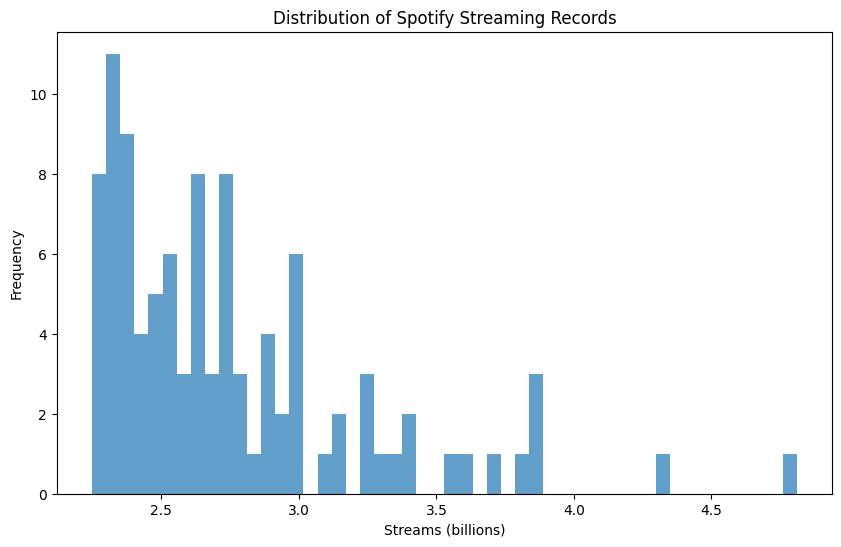

In [115]:
plt.figure(figsize=(10, 6))
plt.hist(df_copy['Streams (billions)'], bins=50, alpha=0.7)
plt.title('Distribution of Spotify Streaming Records')
plt.xlabel('Streams (billions)')
plt.ylabel('Frequency')
plt.show()

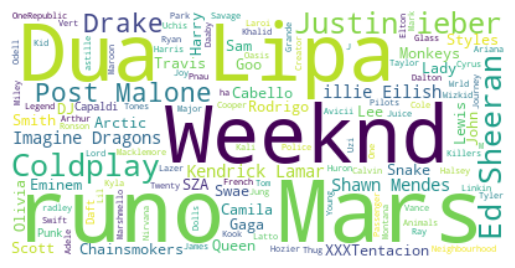

In [123]:
wordcloud = WordCloud( background_color="white").generate(df_copy['Artist(s)'].str.cat(sep=' '))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [124]:
group_by_year = df_copy.groupby(df_copy['Release date'].dt.year).agg({'Streams (billions)': 'sum'}).reset_index()

In [125]:
group_by_year

,Release date,Streams (billions)
0,1975,2.774
1,1979,2.302
2,1981,2.388
3,1983,2.612
4,1984,2.296
5,1991,2.381
6,1995,2.318
7,1998,2.324
8,2000,2.980
9,2001,2.533


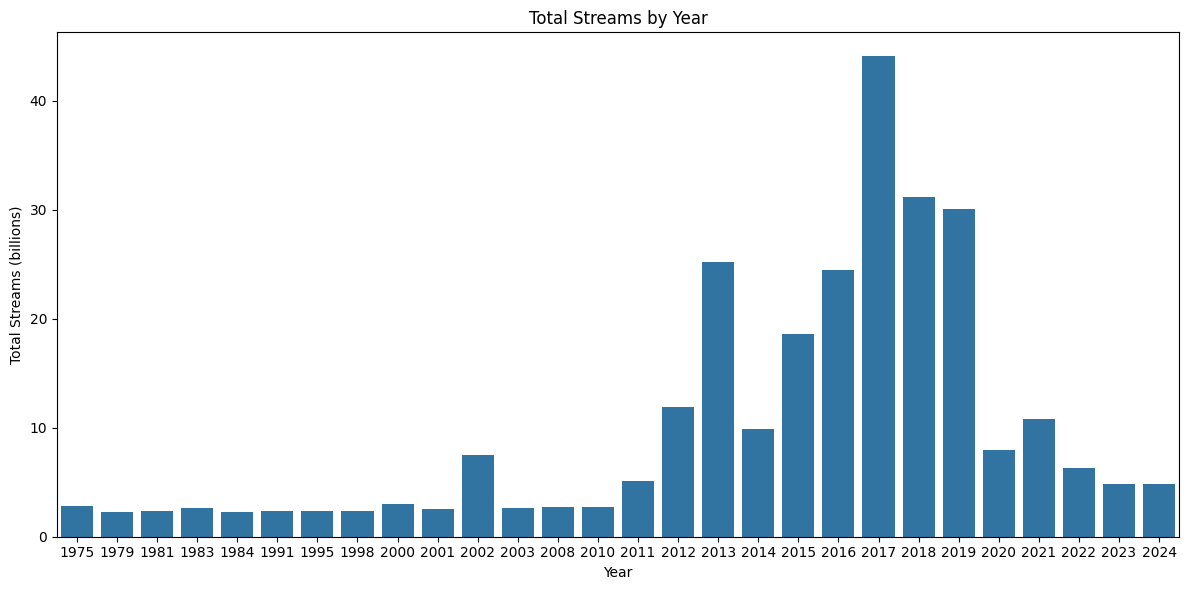

In [129]:
plt.figure(figsize=(12, 6))
sns.barplot(data=group_by_year, x="Release date", y="Streams (billions)")
plt.title("Total Streams by Year")
plt.xlabel("Year")
plt.ylabel("Total Streams (billions)")
plt.tight_layout()
plt.show()